# Employee Attrition Prediction using Machine Learning

## Business Problem

Employee attrition is one of the most significant challenges faced by organizations. Losing experienced employees results in recruitment costs, training expenses, productivity loss, and disruption of business operations.

Human Resource departments need a proactive way to identify employees who are at risk of leaving the organization before attrition occurs.

This project develops a Machine Learning solution capable of predicting employee attrition using demographic, professional, and workplace-related factors.

The insights generated from this project can help HR teams improve employee retention, reduce turnover costs, and build a more stable workforce.

## Project Objectives

The objectives of this project are:

- Analyze employee attrition patterns.
- Identify key factors influencing employee turnover.
- Build predictive machine learning models.
- Compare model performance.
- Determine the most important drivers of attrition.
- Generate actionable HR recommendations.
- Support data-driven employee retention strategies.

## Business Impact

Employee attrition affects organizations through:

- Recruitment and onboarding costs.
- Productivity loss.
- Knowledge transfer issues.
- Reduced team stability.
- Increased workload on remaining employees.

A predictive attrition system allows HR teams to identify high-risk employees early and implement retention strategies before resignations occur.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv("data/HR_Attrition.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [2]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## Dataset Characteristics

The dataset contains employee demographic information, compensation details, job characteristics, work environment indicators, and career progression variables.

The objective is to identify patterns associated with employee turnover and develop predictive models capable of identifying employees at risk of leaving the organization.

In [7]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
round(df["Attrition"].value_counts(normalize=True)*100,2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

## Attrition Distribution Analysis

Attrition is the target variable in this project and indicates whether an employee has left the organization.

### Attrition Distribution

| Attrition Status | Count | Percentage |
|-----------------|--------|------------|
| No (Stayed) | 1233 | 83.88% |
| Yes (Left) | 237 | 16.12% |

### Observations

1. The dataset is significantly imbalanced, with only 16.12% of employees leaving the organization.

2. Most employees remain with the company, making attrition events relatively rare.

3. Class imbalance can cause machine learning models to become biased toward predicting the majority class.

4. To address this challenge, class_weight='balanced' will be used during model training so that attrition cases receive greater importance.

### Business Interpretation

Although only 16.12% of employees left the organization, employee turnover can have a substantial financial impact due to recruitment costs, onboarding expenses, productivity loss, and knowledge transfer challenges.

Accurately identifying employees at risk of attrition can help HR departments implement proactive retention strategies and reduce organizational turnover costs.

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.isnull().sum().sort_values(ascending=False)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

EmployeeCount
Over18
StandardHours


In [13]:
df.dtypes.value_counts()

int64     26
object     9
Name: count, dtype: int64

## Data Quality Assessment

A comprehensive data quality assessment was performed before model development.

### Missing Values

No missing values were identified within the dataset.

Total Missing Values: 0

This indicates a high-quality dataset and eliminates the need for missing value imputation techniques.

### Duplicate Records

No duplicate employee records were detected.

Duplicate Records: 0

This confirms that each observation represents a unique employee.

### Constant Features

The following columns contained only a single unique value across all records:

- EmployeeCount
- Over18
- StandardHours

These variables provide no predictive information and will be removed during preprocessing.

### Data Types

The dataset contains:

- 26 Numerical Features
- 9 Categorical Features

The combination of numerical and categorical variables makes this dataset suitable for both statistical analysis and machine learning classification models.

In [14]:
df = df.drop(
    columns=[
        "EmployeeCount",
        "Over18",
        "StandardHours",
        "EmployeeNumber"
    ]
)

df.shape

(1470, 31)

EmployeeNumber was removed because it functions solely as a unique identifier and does not contain information relevant to employee attrition behavior.

In [15]:
df["Attrition"] = df["Attrition"].map(
    {
        "Yes": 1,
        "No": 0
    }
)

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

The objective of EDA is to identify patterns, trends, and factors associated with employee attrition.

Understanding these relationships enables HR departments to design targeted retention strategies and reduce employee turnover.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


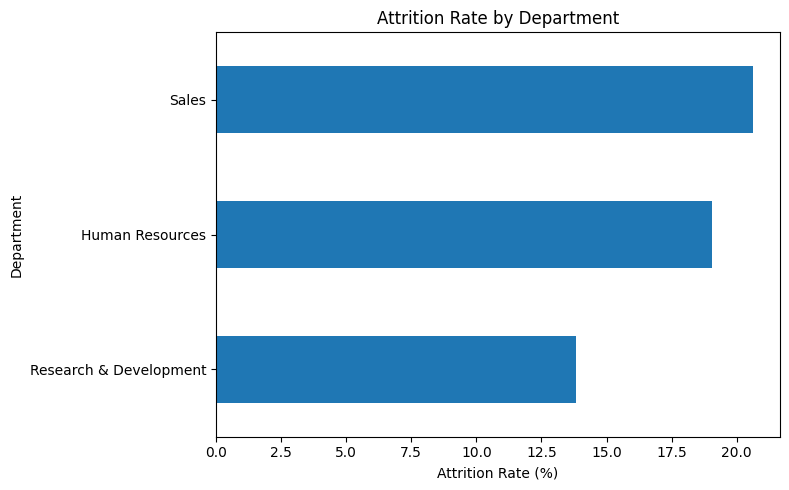

In [17]:
department_attrition[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.tight_layout()

plt.savefig(
    "charts/attrition_by_department.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition.sort_values(
    by=1,
    ascending=False
)

Attrition,0,1
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


In [19]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

overtime_attrition

Attrition,0,1
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


### Key EDA Findings

1. Sales Department recorded the highest attrition rate (20.63%), indicating potential workload and performance-pressure challenges.

2. Sales Representatives experienced the highest employee turnover (39.76%), making them the most at-risk employee group.

3. Employees working overtime showed an attrition rate of 30.53%, compared to only 10.44% among employees not working overtime.

4. Research & Development employees demonstrated the lowest attrition rate (13.84%), suggesting stronger retention and employee satisfaction.

5. Senior positions such as Research Director (2.50%) and Manager (4.90%) exhibited significantly lower turnover rates compared to entry-level roles.

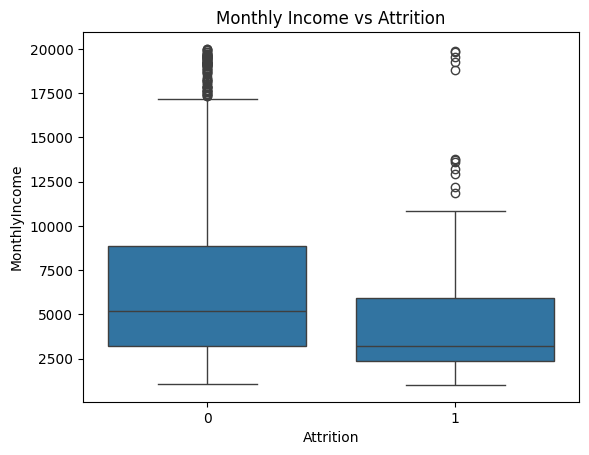

In [20]:
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")
plt.show()

In [21]:
wlb = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

wlb

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


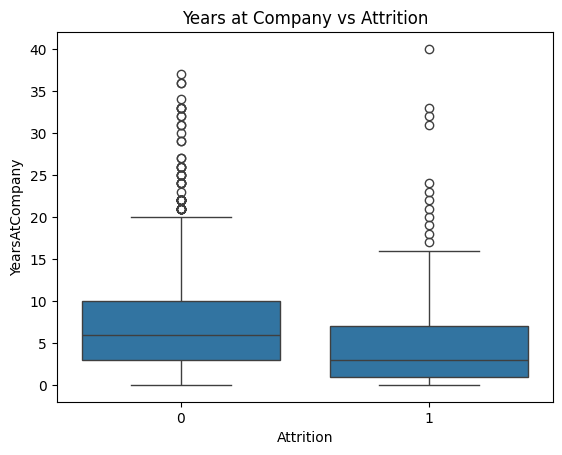

In [22]:
sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company vs Attrition")
plt.show()

### Additional EDA Findings

6. Employees reporting the lowest work-life balance score experienced an attrition rate of 31.25%, significantly higher than other groups.

7. Employees who left the company generally earned lower monthly incomes compared to employees who stayed.

8. Employee turnover is concentrated among employees with shorter tenure, indicating that early-career employees are at higher risk of leaving.

9. Salary contributes to attrition, but overtime and work-life balance appear to be stronger predictors.

10. Improving employee well-being and reducing excessive overtime could significantly reduce attrition rates.

In [23]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [24]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.shape

(1470, 45)

In [25]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [26]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [27]:
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [31]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, lr_pred))

print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

ROC-AUC: 0.7982599707123783


### Logistic Regression Results

The Logistic Regression model achieved a ROC-AUC score of 0.798, indicating good discriminatory power between employees who leave and employees who stay.

The model achieved a recall of 62% for attrition cases, meaning it successfully identified most employees who were at risk of leaving.

Although precision was lower due to class imbalance, the model provides strong interpretability and serves as an effective baseline model for HR analytics.

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [33]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

ROC-AUC: 0.7809458178999052


In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_prob = gb.predict_proba(X_test)[:,1]

In [35]:
print(classification_report(y_test, gb_pred))

print("ROC-AUC:", roc_auc_score(y_test, gb_prob))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC: 0.8043759152381773


Although Gradient Boosting achieved the highest overall accuracy (85%) and ROC-AUC score (0.804), Logistic Regression achieved the highest recall (62%) for attrition cases.

Since employee attrition prediction is primarily a retention problem, identifying employees who are likely to leave is more important than maximizing overall accuracy.

Therefore, Logistic Regression provides better business value for HR departments because it successfully identifies a larger proportion of employees at risk of attrition.

Gradient Boosting demonstrated the strongest overall predictive performance, while Logistic Regression offered the most actionable insights for employee retention strategies.

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                    Feature  Importance
9             MonthlyIncome    0.104935
0                       Age    0.103283
16        TotalWorkingYears    0.094249
43             OverTime_Yes    0.085219
11       NumCompaniesWorked    0.046522
15         StockOptionLevel    0.045737
22     YearsWithCurrManager    0.045160
1                 DailyRate    0.044136
4   EnvironmentSatisfaction    0.037139
6            JobInvolvement    0.036006
2          DistanceFromHome    0.034639
5                HourlyRate    0.031986
8           JobSatisfaction    0.027951
18          WorkLifeBalance    0.027317
10              MonthlyRate    0.021742


## Feature Importance Analysis

Feature importance analysis was performed using the Gradient Boosting model to identify the strongest drivers of employee attrition.

### Top Factors Influencing Employee Attrition

1. Monthly Income
2. Age
3. Total Working Years
4. Overtime
5. Number of Companies Worked
6. Stock Option Level
7. Years With Current Manager
8. Daily Rate
9. Environment Satisfaction
10. Job Involvement

### Business Interpretation

The results suggest that employee attrition is influenced by a combination of compensation, career progression, workload, and workplace experience.

Monthly income emerged as the most influential factor, indicating that compensation remains an important driver of retention.

Overtime was identified as one of the strongest predictors of attrition, supporting earlier EDA findings that employees working overtime are significantly more likely to leave.

Factors such as environment satisfaction, job involvement, and manager relationships also contribute to attrition, highlighting the importance of employee engagement and workplace culture.

## HR Recommendations

### Recommendation 1: Reduce Excessive Overtime

Employees working overtime exhibited an attrition rate of 30.53%, nearly three times higher than employees not working overtime.

HR teams should monitor overtime patterns and implement workload balancing strategies to reduce burnout risk.

### Recommendation 2: Focus on Early-Career Employees

Employees with lower tenure and fewer total working years demonstrated higher attrition tendencies.

Structured onboarding, mentoring programs, and career development plans should be prioritized during the first few years of employment.

### Recommendation 3: Improve Compensation Competitiveness

Monthly income emerged as the most important predictor of attrition.

Organizations should regularly benchmark salaries against industry standards to reduce compensation-related turnover.

### Recommendation 4: Strengthen Employee Engagement

Environment satisfaction and job involvement were among the top predictors of attrition.

Employee feedback programs and engagement initiatives should be expanded to improve retention.

In [37]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [0.75, 0.84, 0.85],
    "Precision": [0.35, 0.57, 0.59],
    "Recall": [0.62, 0.09, 0.21],
    "ROC_AUC": [0.798, 0.781, 0.804]
})

comparison

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic Regression,0.75,0.35,0.62,0.798
1,Random Forest,0.84,0.57,0.09,0.781
2,Gradient Boosting,0.85,0.59,0.21,0.804


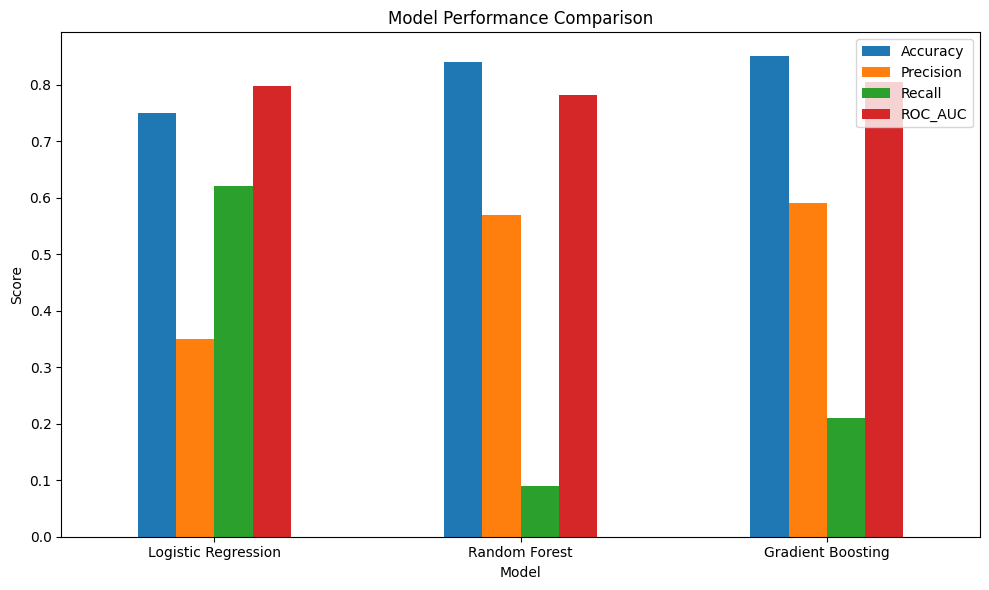

In [38]:
comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "ROC_AUC"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "charts/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

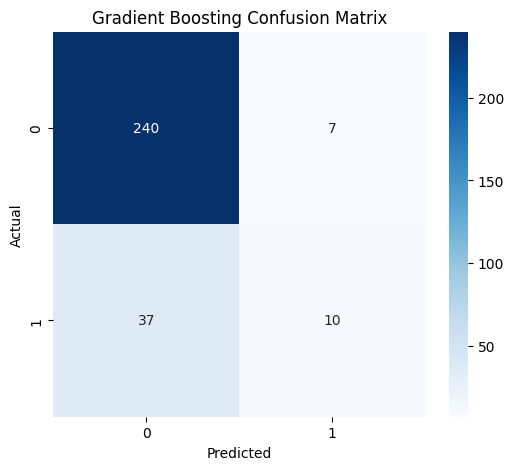

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "charts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

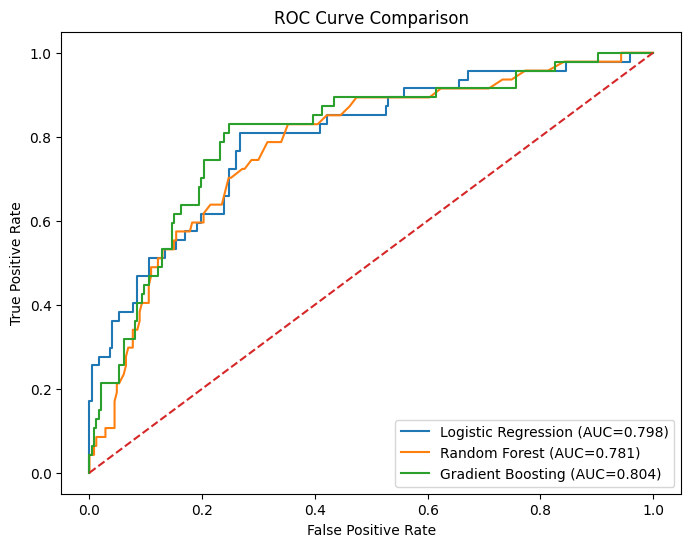

In [40]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression (AUC=0.798)"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest (AUC=0.781)"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label="Gradient Boosting (AUC=0.804)"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig(
    "charts/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

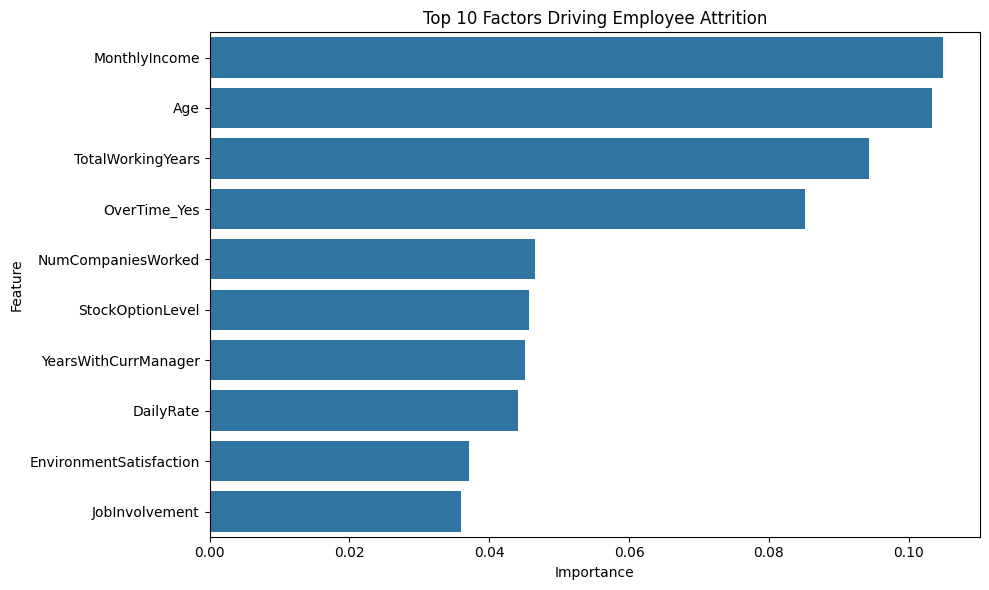

In [41]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Factors Driving Employee Attrition")

plt.tight_layout()

plt.savefig(
    "charts/top10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

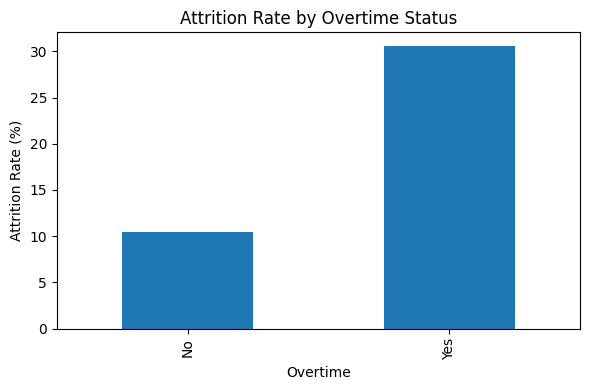

In [42]:
overtime_rates = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

overtime_rates[1].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Attrition Rate by Overtime Status")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Overtime")

plt.tight_layout()

plt.savefig(
    "charts/overtime_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Executive Summary

This project developed an Employee Attrition Prediction system using machine learning techniques to identify employees at risk of leaving the organization.

The analysis revealed that employee attrition is primarily influenced by compensation, age, experience, overtime, workplace satisfaction, and manager relationships.

Sales employees exhibited the highest attrition rate among departments, while Sales Representatives experienced the highest turnover among job roles.

Employees working overtime demonstrated nearly three times the attrition rate of employees not working overtime, making workload management a critical retention factor.

Among the evaluated models, Gradient Boosting achieved the highest overall predictive performance, while Logistic Regression demonstrated superior recall and business interpretability.

The findings suggest that organizations can significantly reduce turnover by improving work-life balance, monitoring overtime, strengthening employee engagement, and implementing targeted retention strategies for high-risk employee groups.